# Marge Initiale — Pipeline complète

Ce notebook exécute la chaîne de calcul de la Marge Initiale (IM) de bout en bout,
conformément à la **Note méthodologique** (Mars 2026, Quant Factory).

**Pipeline :**
1. Chargement et nettoyage de la courbe ZC
2. Construction des prix zéro-coupon
3. Calcul des returns historiques à horizon HP
4. Estimation EWMA de la volatilité conditionnelle
5. Construction des scénarios FHS scalés et stress bruts
6. Full revaluation d'un portefeuille obligataire
7. Calcul de l'Expected Shortfall (ES) au seuil 99 %
8. Calcul de la Marge Initiale hybride FHS–Stress


## 0. Setup et imports

In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Résolution du chemin racine du projet
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print('ROOT =', ROOT)


ROOT = C:\Users\ismai\Desktop\PFE\PFE_ismail_2026\im_ccp_project


In [2]:
from src.config import ModelConfig
from src.market_data.loader import load_zero_coupon_curve
from src.market_data.cleaner import clean_zero_coupon_curve
from src.market_data.curve import get_curve_at_date
from src.risk.risk_factors import build_zero_coupon_price_matrix, compute_historical_returns
from src.risk.ewma import get_ewma_window, compute_ewma_volatility
from src.risk.scenarios import build_scaled_scenarios, build_unscaled_scenarios
from src.risk.pnl import (
    compute_portfolio_pnl_under_scenarios,
    compute_portfolio_initial_value,
    compute_losses_from_pnl,
)
from src.risk.es import compute_es_from_pnl
from src.risk.im import compute_initial_margin


## 1. Paramétrage du modèle

Les paramètres de référence sont définis dans `src/constants.py` et encapsulés dans `ModelConfig`.
Cf. Note méthodologique, Tableau 4.


In [3]:
config = ModelConfig(
    LP=2500,
    HP=5,
    SW=60,
    lambda_ewma=0.94,
    t0='2025-05-30',
    stress_start='2022-01-01',
    stress_end='2023-12-31',
    alpha=0.99,
    FHS_w=0.75,
    Stress_w=0.25,
    metric='ES',
    nominal=100.0,
)

config.validate()
print(f'Fenêtre totale requise : LP + SW + 1 = {config.total_window} observations')
config


Fenêtre totale requise : LP + SW + 1 = 2561 observations


ModelConfig(LP=2500, HP=5, SW=60, lambda_ewma=0.94, t0='2025-05-30', stress_start='2022-01-01', stress_end='2023-12-31', alpha=0.99, FHS_w=0.75, Stress_w=0.25, apc_buffer_pct=0.25, apc_floor_pct=0.25, metric='ES', nominal=100.0, model_version='1.1.0')

## 2. Chargement et nettoyage de la courbe ZC

**§4 de la note** — Pipeline : déduplication, tri chronologique, typage numérique, suppression des NaN.


In [4]:
zc_curve_df = load_zero_coupon_curve(ROOT / 'data' / 'raw' / 'ZeroCouponCurve.csv')
zc_curve_df = clean_zero_coupon_curve(zc_curve_df)

print(f'Shape        : {zc_curve_df.shape}')
print(f'Piliers      : {list(zc_curve_df.columns[:5])} ... {list(zc_curve_df.columns[-3:])}')
print(f'Période      : {zc_curve_df.index.min().date()} → {zc_curve_df.index.max().date()}')
print(f'Nb piliers   : {len(zc_curve_df.columns)}')
zc_curve_df.tail(3)


Shape        : (3439, 33)
Piliers      : [0.25, 0.5, 1.0, 2.0, 3.0] ... [29.0, 30.0, 31.0]
Période      : 2012-03-27 → 2025-05-30
Nb piliers   : 33


,0.25,0.50,1.00,2.00,3.00,4.00,5.00,6.00,7.00,8.00,...,22.00,23.00,24.00,25.00,26.00,27.00,28.00,29.00,30.00,31.00
date,,,,,,,,,,,,,,,,,,,,,
2025-05-28,0.006444,0.008477,0.003197,0.032941,0.032949,0.028559,0.024170,0.023291,0.025482,0.027672,...,0.039696,0.039199,0.038703,0.038206,0.037709,0.037212,0.036716,0.036219,0.035722,0.040384
2025-05-29,0.006040,0.008274,0.003197,0.032939,0.032910,0.028533,0.024156,0.023241,0.025441,0.027641,...,0.039690,0.039194,0.038697,0.038201,0.037704,0.037207,0.036711,0.036214,0.035718,0.040377
2025-05-30,0.006040,0.008274,0.003100,0.032893,0.032913,0.028528,0.024143,0.023230,0.025431,0.027632,...,0.039535,0.039038,0.038542,0.038045,0.037548,0.037052,0.036555,0.036058,0.035562,0.040066


## 3. Courbe courante à t₀

Extraction de la courbe zéro-coupon à la date d'évaluation.


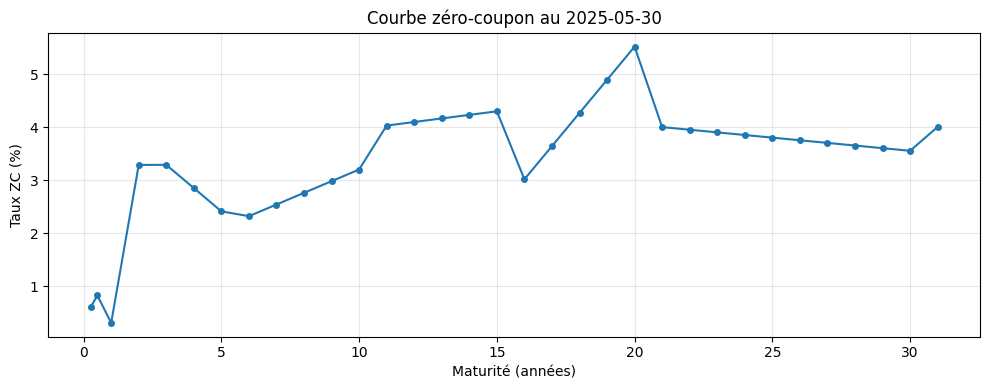

In [5]:
curve_t0 = get_curve_at_date(zc_curve_df, config.t0)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(curve_t0.index, curve_t0.values * 100, 'o-', markersize=4, linewidth=1.5)
ax.set_xlabel('Maturité (années)')
ax.set_ylabel('Taux ZC (%)')
ax.set_title(f'Courbe zéro-coupon au {config.t0}')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Prix zéro-coupon et returns historiques

**§5.1, éq. (2)** : $P(t, T) = N / (1 + r(t, T))^T$

**§5.2, éq. (3)** : $R(t, T_k) = P(t, T_k) / P(t - HP, T_k) - 1$


In [6]:
zc_price_df = build_zero_coupon_price_matrix(zc_curve_df, nominal=config.nominal)
returns_df = compute_historical_returns(zc_price_df, HP=config.HP)

print(f'Shape prix ZC  : {zc_price_df.shape}')
print(f'Shape returns  : {returns_df.shape}')
print(f'Returns période: {returns_df.index.min().date()} → {returns_df.index.max().date()}')


Shape prix ZC  : (3439, 33)
Shape returns  : (3434, 33)
Returns période: 2012-04-03 → 2025-05-30


## 5. Volatilité conditionnelle EWMA

**§6.2, éq. (4)** : $\sigma^2_t = \lambda \cdot \sigma^2_{t-1} + (1 - \lambda) \cdot r^2_{t-1}$

Fenêtre d'estimation : LP + SW + 1 = 311 observations. Les 60 premières servent au
warm-up (≈ 2.6 demi-vies pour λ = 0.97).


EWMA window : (2561, 33)
Vol shape   : (2561, 33)


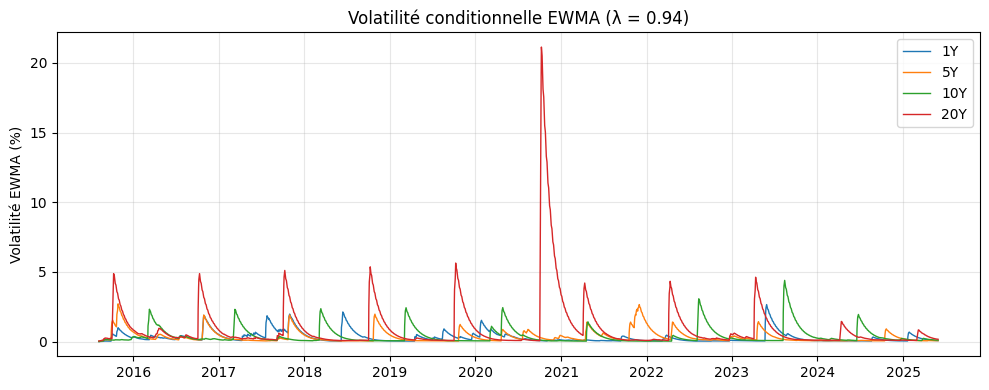

In [7]:
ewma_window = get_ewma_window(returns_df, t0=config.t0, LP=config.LP, SW=config.SW)
vol_df = compute_ewma_volatility(ewma_window, lambda_=config.lambda_ewma)

print(f'EWMA window : {ewma_window.shape}')
print(f'Vol shape   : {vol_df.shape}')

# Visualisation de la volatilité EWMA sur quelques piliers
fig, ax = plt.subplots(figsize=(10, 4))
for pillar in [1.0, 5.0, 10.0, 20.0]:
    ax.plot(vol_df.index, vol_df[pillar] * 100, label=f'{pillar:.0f}Y', linewidth=1)
ax.set_ylabel('Volatilité EWMA (%)')
ax.set_title(f'Volatilité conditionnelle EWMA (λ = {config.lambda_ewma})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Construction des scénarios

### 6a. Scénarios FHS scalés
**§7.1, éq. (7-8)** : $\tilde{R}(t, T_k) = \varphi(t, T_k) \cdot R(t, T_k)$ avec
$\varphi = (\sigma_{t_0} + \sigma_t) / (2 \sigma_t)$

### 6b. Scénarios de stress bruts
**§7.2, éq. (9)** : Returns non rescalés sur la fenêtre [2022-01-01, 2023-12-31].


In [8]:
scaled_df = build_scaled_scenarios(
    returns_df=returns_df,
    vol_df=vol_df,
    t0=config.t0,
    LP=config.LP,
)

unscaled_df = build_unscaled_scenarios(
    returns_df=returns_df,
    stress_start=config.stress_start,
    stress_end=config.stress_end,
)

print(f'Scénarios FHS (scalés)      : {scaled_df.shape}')
print(f'Scénarios stress (non scalés): {unscaled_df.shape}')


Scénarios FHS (scalés)      : (2500, 33)
Scénarios stress (non scalés): (520, 33)


## 7. Définition du portefeuille test

Portefeuille de 3 positions obligataires à taux fixe.
La valorisation utilise la full revaluation (§8.1, éq. 10).


In [9]:
portfolio = [
    {'name': 'MOROCCO 2014 5.45% 06/08/29', 'maturity': 4.47,  'coupon_rate': 0.0545, 'nominal': 100.0, 'frequency': 1, 'quantity': 192678.0},
    {'name': 'MOROCCO 2014 5.6% 16/04/29',  'maturity': 4.16,  'coupon_rate': 0.0560, 'nominal': 100.0, 'frequency': 1, 'quantity': 105696.0},
    {'name': 'MOROCCO 2014 5.85% 31/03/34', 'maturity': 9.12,  'coupon_rate': 0.0585, 'nominal': 100.0, 'frequency': 1, 'quantity': -92066.0}, # Short position (PS = -1)
    {'name': 'MOROCCO 2021 3.45% 20/02/51', 'maturity': 26.02, 'coupon_rate': 0.0345, 'nominal': 100.0, 'frequency': 1, 'quantity': 13829.0},
    {'name': 'MOROCCO 2022 2.4% 14/06/32',  'maturity': 7.33,  'coupon_rate': 0.0240, 'nominal': 100.0, 'frequency': 1, 'quantity': 58940.0},
    {'name': 'MOROCCO 2024 2.7% 19/01/26',  'maturity': 0.92,  'coupon_rate': 0.0270, 'nominal': 100.0, 'frequency': 1, 'quantity': 111563.0},
    {'name': 'MOROCCO 2024 4 1/2% 19/04/55','maturity': 30.19, 'coupon_rate': 0.0450, 'nominal': 100.0, 'frequency': 1, 'quantity': 177496.0},
    {'name': 'MOROCCO 2024 4.9% 15/02/55',  'maturity': 30.01, 'coupon_rate': 0.0490, 'nominal': 100.0, 'frequency': 1, 'quantity': 153059.0}
]

current_zc_price_curve = zc_price_df.loc[config.t0]
initial_value = compute_portfolio_initial_value(current_zc_price_curve, portfolio)

print(f'Valeur initiale V(t₀) = {initial_value:.2f}')
for i, pos in enumerate(portfolio):
    print(f"  Position {i+1}: {pos['quantity']}x obligation {pos['maturity']:.0f}Y, coupon {pos['coupon_rate']*100:.1f}%")


Valeur initiale V(t₀) = 81687674.58
  Position 1: 192678.0x obligation 4Y, coupon 5.5%
  Position 2: 105696.0x obligation 4Y, coupon 5.6%
  Position 3: -92066.0x obligation 9Y, coupon 5.9%
  Position 4: 13829.0x obligation 26Y, coupon 3.5%
  Position 5: 58940.0x obligation 7Y, coupon 2.4%
  Position 6: 111563.0x obligation 1Y, coupon 2.7%
  Position 7: 177496.0x obligation 30Y, coupon 4.5%
  Position 8: 153059.0x obligation 30Y, coupon 4.9%


## 8. PnL sous scénarios

**§9, éq. (16-17)** : Perturbation multiplicative de la courbe ZC puis full revaluation.

$P^{(s)}(t_0, T_k) = P(t_0, T_k) \cdot (1 + \tilde{R}^{(s)}(T_k))$

$PnL^{(s)} = V^{(s)} - V(t_0)$


In [10]:
pnl_scaled = compute_portfolio_pnl_under_scenarios(
    current_zc_price_curve=current_zc_price_curve,
    scenario_returns_df=scaled_df,
    portfolio=portfolio,
)

pnl_unscaled = compute_portfolio_pnl_under_scenarios(
    current_zc_price_curve=current_zc_price_curve,
    scenario_returns_df=unscaled_df,
    portfolio=portfolio,
)

print(f'PnL FHS    : {len(pnl_scaled)} scénarios, range [{pnl_scaled.min():.2f}, {pnl_scaled.max():.2f}]')
print(f'PnL Stress : {len(pnl_unscaled)} scénarios, range [{pnl_unscaled.min():.2f}, {pnl_unscaled.max():.2f}]')


PnL FHS    : 2500 scénarios, range [-3173185.94, 3668094.07]
PnL Stress : 520 scénarios, range [-3045242.17, 2470747.94]


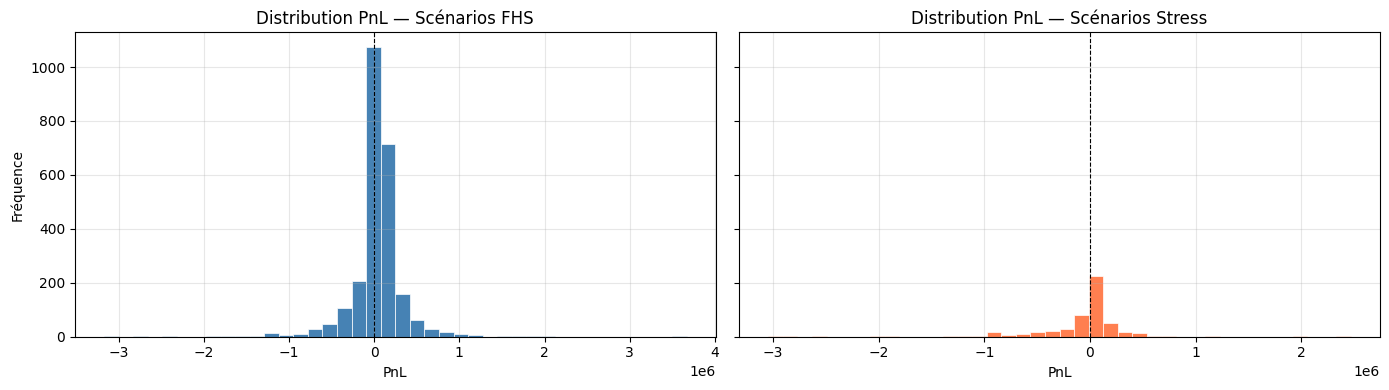

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

axes[0].hist(pnl_scaled, bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=0.8)
axes[0].set_title('Distribution PnL — Scénarios FHS')
axes[0].set_xlabel('PnL')
axes[0].set_ylabel('Fréquence')
axes[0].grid(True, alpha=0.3)

axes[1].hist(pnl_unscaled, bins=40, color='coral', edgecolor='white', linewidth=0.5)
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_title('Distribution PnL — Scénarios Stress')
axes[1].set_xlabel('PnL')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 9. Expected Shortfall

**§10, éq. (18)** : $ES_\alpha = \frac{1}{k} \sum_{j=1}^{k} L_{(j)}$ avec $k = \lceil (1 - \alpha) \cdot n \rceil$

Pour α = 99% et n = 250 : k = 3 (moyenne des 3 pires pertes).


In [12]:
ES_scaled = compute_es_from_pnl(pnl_scaled, alpha=config.alpha)
ES_unscaled = compute_es_from_pnl(pnl_unscaled, alpha=config.alpha)

print(f'ES FHS (scalé)       = {ES_scaled:.6f}')
print(f'ES Stress (non scalé) = {ES_unscaled:.6f}')

# Visualisation des pertes extrêmes
import math
losses_scaled = compute_losses_from_pnl(pnl_scaled).sort_values(ascending=False)
k = math.ceil((1 - config.alpha) * len(losses_scaled))
print(f'\nLes k = {k} pires pertes FHS :')
for i in range(k):
    print(f'  L({i+1}) = {losses_scaled.iloc[i]:.6f}  (date: {losses_scaled.index[i].date()})')


ES FHS (scalé)       = 1554514.909312
ES Stress (non scalé) = 2713758.701501

Les k = 26 pires pertes FHS :
  L(1) = 3173185.937690  (date: 2018-12-04)
  L(2) = 2660931.054965  (date: 2021-12-06)
  L(3) = 2398291.715311  (date: 2016-10-21)
  L(4) = 1962013.683717  (date: 2022-12-23)
  L(5) = 1732120.493402  (date: 2023-01-10)
  L(6) = 1727649.672054  (date: 2023-01-05)
  L(7) = 1681745.069365  (date: 2017-12-04)
  L(8) = 1558357.470305  (date: 2022-10-03)
  L(9) = 1552018.745715  (date: 2017-10-23)
  L(10) = 1543820.777915  (date: 2023-01-13)
  L(11) = 1504379.811715  (date: 2023-01-09)
  L(12) = 1462368.884330  (date: 2016-10-24)
  L(13) = 1334170.366769  (date: 2017-10-24)
  L(14) = 1266004.784030  (date: 2022-10-06)
  L(15) = 1256227.870806  (date: 2016-10-25)
  L(16) = 1254589.706821  (date: 2015-12-04)
  L(17) = 1235766.445356  (date: 2016-10-26)
  L(18) = 1230769.865614  (date: 2024-12-04)
  L(19) = 1228498.567516  (date: 2016-10-27)
  L(20) = 1223717.081891  (date: 2022-12-27)
 

## 10. Marge Initiale

**§11, éq. (19-20)** :

$ES_{hybrid} = w_{FHS} \cdot ES^{FHS}_\alpha + w_{stress} \cdot ES^{stress}_\alpha$

$IM = \max(ES^{FHS}_\alpha,\; ES_{hybrid})$

Le plancher garantit que la composante stress ne réduit jamais la marge.


In [13]:
IM = compute_initial_margin(
    es_fhs=ES_scaled,
    es_stress=ES_unscaled,
    fhs_w=config.FHS_w,
    stress_w=config.Stress_w,
)

ES_hybrid = config.FHS_w * ES_scaled + config.Stress_w * ES_unscaled
floor_binding = ES_scaled >= ES_hybrid

print('=' * 55)
print(f'  ES FHS (scalé)              = {ES_scaled:>12.6f}')
print(f'  ES Stress (non scalé)       = {ES_unscaled:>12.6f}')
print(f'  ES Hybrid (avant plancher)  = {ES_hybrid:>12.6f}')
print(f'  Plancher contraignant ?        {"OUI" if floor_binding else "NON"}')
print(f'  ─────────────────────────────────────────────────')
print(f'  MARGE INITIALE (IM)         = {IM:>12.6f}')
print('=' * 55)


  ES FHS (scalé)              = 1554514.909312
  ES Stress (non scalé)       = 2713758.701501
  ES Hybrid (avant plancher)  = 1844325.857359
  Plancher contraignant ?        NON
  ─────────────────────────────────────────────────
  MARGE INITIALE (IM)         = 1844325.857359


## 11. Résumé final

In [14]:
summary = pd.DataFrame({
    'Paramètre': [
        'Date évaluation (t₀)', 'Lookback Period (LP)', 'Holding Period (HP)',
        'Smoothing Window (SW)', 'Lambda EWMA (λ)', 'Alpha ES (α)',
        'Poids FHS', 'Poids Stress',
        'Fenêtre stress', 'Nb scénarios FHS', 'Nb scénarios Stress',
        'Valeur portefeuille V(t₀)',
        'ES FHS', 'ES Stress', 'Marge Initiale (IM)',
    ],
    'Valeur': [
        config.t0, config.LP, config.HP,
        config.SW, config.lambda_ewma, config.alpha,
        config.FHS_w, config.Stress_w,
        f'{config.stress_start} → {config.stress_end}',
        len(pnl_scaled), len(pnl_unscaled),
        f'{initial_value:.2f}',
        f'{ES_scaled:.6f}', f'{ES_unscaled:.6f}', f'{IM:.6f}',
    ],
})

summary.style.hide(axis='index')


Paramètre,Valeur
Date évaluation (t₀),2025-05-30
Lookback Period (LP),2500
Holding Period (HP),5
Smoothing Window (SW),60
Lambda EWMA (λ),0.940000
Alpha ES (α),0.990000
Poids FHS,0.750000
Poids Stress,0.250000
Fenêtre stress,2022-01-01 → 2023-12-31
Nb scénarios FHS,2500


In [15]:
(IM/initial_value)*100

2.257777402646077

In [16]:
# Backtesting du modele IM - validation independante (EMIR Art. 49)
from src.backtesting import (
    run_im_backtest,
    summarize_backtest,
    kupiec_pof_test,
    christoffersen_independence_test,
    christoffersen_conditional_coverage_test,
    basel_traffic_light,
)

# Execution du backtest sur fenetre out-of-sample
backtest_results = run_im_backtest(
    zc_curve_df=zc_curve_df,
    portfolio=portfolio,
    config=config,
    start='2024-01-01',
    end='2025-05-30',
    step=1,
)

bt_summary = summarize_backtest(backtest_results, alpha=config.alpha)

# -------- Rapport detaille --------
n_obs = bt_summary['n_obs']
n_exc = bt_summary['n_exceptions']
obs_rate = bt_summary['exception_rate']
exp_rate = bt_summary['expected_rate']
expected_n = exp_rate * n_obs

print('=' * 70)
print(f"  RAPPORT DE BACKTESTING - {n_obs} jours ouvres backtests")
print('=' * 70)
print(f"  Periode                     : 2024-01-01 -> 2025-05-30")
print(f"  Niveau de confiance (alpha) : {config.alpha:.2%}")
print(f"  Exceptions observees        : {n_exc} / {n_obs}")
print(f"  Taux d'exception observe    : {obs_rate:.4%}")
print(f"  Taux d'exception attendu    : {exp_rate:.4%}  (E[N] = {expected_n:.1f})")
print('-' * 70)

# Test de Kupiec POF
pof = bt_summary['kupiec_pof']
print(f"  Kupiec POF (couverture inconditionnelle)")
print(f"    LR statistic = {pof.statistic:.4f}, p-value = {pof.p_value:.4f}")
print(f"    Verdict      : {'REJET de H0 a 5%' if pof.rejected_at_5pct else 'Non rejet de H0 a 5%'}")
print('-' * 70)

# Test de Christoffersen IND
ind = bt_summary['christoffersen_ind']
print(f"  Christoffersen IND (independance des exceptions)")
print(f"    LR statistic = {ind.statistic:.4f}, p-value = {ind.p_value:.4f}")
print(f"    Verdict      : {'REJET (clustering)' if ind.rejected_at_5pct else 'Pas de clustering'}")
print('-' * 70)

# Test de Christoffersen CC
cc = bt_summary['christoffersen_cc']
print(f"  Christoffersen CC (couverture conditionnelle = POF + IND)")
print(f"    LR statistic = {cc.statistic:.4f}, p-value = {cc.p_value:.4f}")
print(f"    Verdict      : {'REJET de H0 a 5%' if cc.rejected_at_5pct else 'Non rejet de H0 a 5%'}")
print('-' * 70)

# Bale Traffic Light
tl = bt_summary['basel_traffic_light']
print(f"  Bale Traffic Light")
print(f"    Couleur       : {tl['color']}")
print(f"    Multiplicateur: {tl['multiplier']:.2f}")
print(f"    Verdict       : {tl['verdict']}")
print('=' * 70)

# -------- Verdict de synthese (gestion du sur-conservatisme) --------
print()
print('  VERDICT DE SYNTHESE')
print('-' * 70)
if n_exc == 0 and pof.rejected_at_5pct:
    print("  [!] SUR-CONSERVATISME DETECTE")
    print("      Le verdict Bale (GREEN) est trompeur dans ce cas : Bale ne")
    print("      teste que la borne superieure. Le test de Kupiec rejette")
    print("      H0 par DEFAUT de couverture (modele trop conservateur).")
    print("      Action : recalibrer (lambda, scaling, poids stress) pour")
    print("      reduire la sur-marge et le cout de collateral aux adherents.")
elif obs_rate > 2 * exp_rate:
    print("  [!] SOUS-COUVERTURE DETECTEE")
    print("      Action : recalibrer immediatement, IM insuffisante.")
elif pof.rejected_at_5pct or cc.rejected_at_5pct:
    print("  [!] TESTS STATISTIQUES NON PASSANTS - investigation requise")
else:
    print("  [OK] Modele statistiquement valide.")
print('=' * 70)

backtest_results.head()


  RAPPORT DE BACKTESTING - 365 jours ouvres backtests
  Periode                     : 2024-01-01 -> 2025-05-30
  Niveau de confiance (alpha) : 99.00%
  Exceptions observees        : 0 / 365
  Taux d'exception observe    : 0.0000%
  Taux d'exception attendu    : 1.0000%  (E[N] = 3.7)
----------------------------------------------------------------------
  Kupiec POF (couverture inconditionnelle)
    LR statistic = 7.3367, p-value = 0.0068
    Verdict      : REJET de H0 a 5%
----------------------------------------------------------------------
  Christoffersen IND (independance des exceptions)
    LR statistic = 0.0000, p-value = 1.0000
    Verdict      : Pas de clustering
----------------------------------------------------------------------
  Christoffersen CC (couverture conditionnelle = POF + IND)
    LR statistic = 7.3367, p-value = 0.0255
    Verdict      : REJET de H0 a 5%
----------------------------------------------------------------------
  Bale Traffic Light
    Couleur     

,IM,V0,V_HP,loss,loss_pct_v0,exception
date,,,,,,
2024-01-01,2.318920e+06,7.714137e+07,7.761428e+07,-472909.457940,-0.006130,False
2024-01-02,2.299576e+06,7.714915e+07,7.774254e+07,-593389.599531,-0.007691,False
2024-01-03,2.294939e+06,7.731035e+07,7.793963e+07,-629284.505170,-0.008140,False
2024-01-04,2.283613e+06,7.731830e+07,7.794848e+07,-630183.706240,-0.008151,False
2024-01-05,2.274216e+06,7.732968e+07,7.808693e+07,-757253.049197,-0.009793,False


## 12. Anti-procyclicite (EMIR Art. 28)

Calcul des indicateurs APC sur la serie historique d'IM produite par le
backtest, et application du plancher option (c) du RTS 153/2013 :

$$IM_{floored}(t) = \max\big(IM(t),\; 25\% \cdot \max_{s \in [t-2500;t]} IM(s)\big)$$


  IM brute                =   1,844,325.86
  Buffer option (a) 25%   =     461,081.46
  IM avec buffer publiee  =   2,305,407.32
  Ratio IM publiee / V0   =        2.8222%

 RAPPORT ANTI-PROCYCLICITE (APC) - EMIR Art. 28 / RTS 153/2013
  Nombre d'observations          : 365
  IM moyenne                     : 2159208.8473
  IM ecart-type                  :  328562.4748
  IM min                         : 1742702.4944
  IM max                         : 3275187.2446
  Ratio APC (min/max)            :       0.5321
  ---------------------------------------------------------------
  Variation J/J moyenne          :     -0.0314%
  Variation J/J ecart-type       :      2.5018%
  Variation J/J 95e percentile   :     +3.1302%
  Variation J/J 99e percentile   :     +7.7205%
  Pire hausse J/J                :    +27.5261%
  Pire baisse J/J                :    -16.1902%
  Nb d'alertes (|delta|>seuil)   : 4
  ---------------------------------------------------------------
  Pire call de marge cumule 

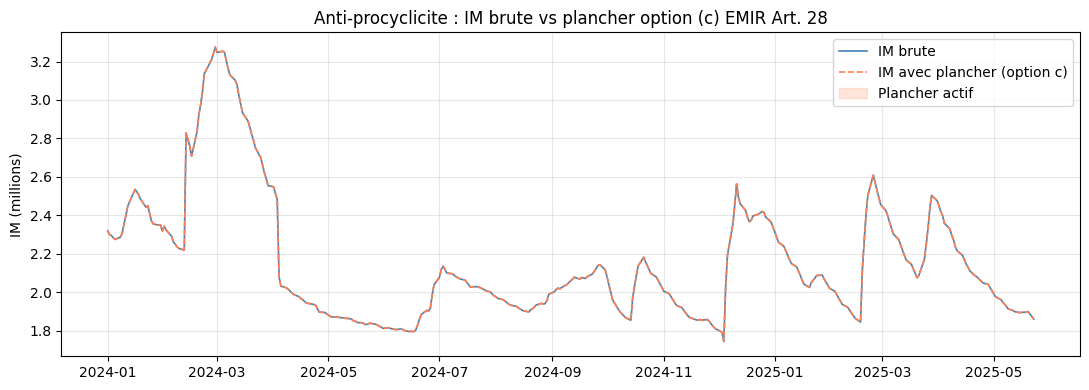

In [17]:
from src.apc import (
    apply_floor_option_c,
    apply_buffer_option_a,
    compute_apc_metrics,
    apc_report,
)

# Serie historique d IM produite par le backtest
im_history = backtest_results['IM'].copy()

# Application du plancher option (c) EMIR Art. 28
im_floored = apply_floor_option_c(
    im_history,
    floor_pct=config.apc_floor_pct,
    lookback_days=config.LP,
)

# Buffer option (a) sur l IM courante
buffer = apply_buffer_option_a(IM, buffer_pct=config.apc_buffer_pct)
print(f"  IM brute                = {buffer['im_raw']:>14,.2f}")
print(f"  Buffer option (a) 25%   = {buffer['buffer']:>14,.2f}")
print(f"  IM avec buffer publiee  = {buffer['im_with_buffer']:>14,.2f}")
print(f"  Ratio IM publiee / V0   = {buffer['im_with_buffer']/initial_value:>14.4%}")
print()

# Indicateurs APC consolides
metrics = compute_apc_metrics(
    im_history=im_history,
    apc_window=250,
    horizons=(1, 5, 10, 20, 60),
    floored_history=im_floored,
)

# Rapport texte pret pour la documentation modele
print(apc_report(metrics))

# Visualisation IM brute vs floored
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(im_history.index, im_history.values / 1e6,
        label='IM brute', linewidth=1.2, color='steelblue')
ax.plot(im_floored.index, im_floored.values / 1e6,
        label='IM avec plancher (option c)', linewidth=1.2,
        color='coral', linestyle='--')
ax.fill_between(im_history.index,
                im_history.values / 1e6,
                im_floored.values / 1e6,
                where=(im_floored > im_history),
                alpha=0.2, color='coral', label='Plancher actif')
ax.set_ylabel('IM (millions)')
ax.set_title('Anti-procyclicite : IM brute vs plancher option (c) EMIR Art. 28')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
